In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges converted to numeric.")
print("Missing values:", df["TotalCharges"].isna().sum())

TotalCharges converted to numeric.
Missing values: 0


In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [5]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
df.head()

In [ ]:
df = pd.read_csv("../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

In [ ]:
import pandas as pd
import numpy as np

print("Python environment is working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

In [14]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [15]:
df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"]).round(2)

,mean,median,min,max
Churn,,,,
No,37.57,38.0,0,72
Yes,17.98,10.0,1,72


In [16]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


In [ ]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


In [17]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [18]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [19]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


In [20]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


In [21]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [22]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


In [23]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


In [24]:
pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


In [25]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


In [26]:
pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


In [27]:
pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
StreamingTV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


In [28]:
pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
StreamingMovies,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


In [29]:
categorical_columns = df.select_dtypes(include="str").columns.tolist()

print(categorical_columns)
print("\nNumber of categorical columns:", len(categorical_columns))

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Number of categorical columns: 17


In [30]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Features:", X.shape)
print("Target:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features: (7043, 19)
Target: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [31]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

Original features: 19
Encoded features: 30


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 30)
Testing features: (1409, 30)
Training target: (5634,)
Testing target: (1409,)


In [33]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


d:\Portfolio\Customer_Churn_Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Performance")
print("-" * 35)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.807
Precision: 0.6584
Recall   : 0.5668
F1 Score : 0.6092
ROC-AUC  : 0.8418


In [36]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("-" * 35)
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest Performance
-----------------------------------
Accuracy : 0.775
Precision: 0.5661
Recall   : 0.6524
F1 Score : 0.6062
ROC-AUC  : 0.8276


In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.177724
1,tenure,0.166075
2,MonthlyCharges,0.151506
25,Contract_Two year,0.059117
10,InternetService_Fiber optic,0.042793
28,PaymentMethod_Electronic check,0.037402
24,Contract_One year,0.029129
13,OnlineSecurity_Yes,0.028249
4,gender_Male,0.025777
26,PaperlessBilling_Yes,0.024040


In [39]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Odds_Ratio
10,InternetService_Fiber optic,0.776154,2.173099
3,TotalCharges,0.514285,1.672442
23,StreamingMovies_Yes,0.257227,1.293338
21,StreamingTV_Yes,0.257144,1.293231
9,MultipleLines_Yes,0.216167,1.241310
26,PaperlessBilling_Yes,0.182034,1.199655
28,PaymentMethod_Electronic check,0.181103,1.198539
0,SeniorCitizen,0.053073,1.054507
17,DeviceProtection_Yes,0.053048,1.054480
29,PaymentMethod_Mailed check,0.032262,1.032788


Confusion Matrix:
[[925 110]
 [162 212]]


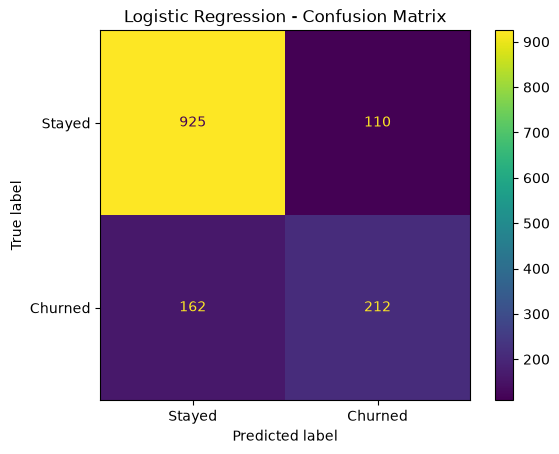

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [41]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.807,0.6584,0.5668,0.6092,0.8418
1,Random Forest,0.775,0.5661,0.6524,0.6062,0.8276


In [42]:
predictions = X_test.copy()

predictions["Actual_Churn"] = y_test.values
predictions["Predicted_Churn"] = y_pred
predictions["Churn_Probability"] = y_prob

predictions.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,True,False,True,True,True,False,False,0,0,0.044982
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0,1,0.683234
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,True,True,False,False,0,0,0.056542
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,True,False,0,0,0.407806
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,True,False,True,True,True,False,False,0,0,0.021666


In [43]:
powerbi_predictions = df.loc[X_test.index].copy()

powerbi_predictions["Actual_Churn"] = y_test
powerbi_predictions["Predicted_Churn"] = y_pred
powerbi_predictions["Churn_Probability"] = y_prob

powerbi_predictions.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Actual_Churn,Predicted_Churn,Churn_Probability
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No,0,0,0.044982
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,0,1,0.683234
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,No,One year,Yes,Credit card (automatic),78.35,3211.20,No,0,0,0.056542
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,No,0,0,0.407806
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No,0,0,0.021666


In [44]:
powerbi_predictions.to_csv(
    "../PowerBI/customer_churn_predictions.csv",
    index=False
)

print("Power BI dataset exported successfully!")

Power BI dataset exported successfully!
